In [31]:
import pandas as pd
df=pd.read_csv("titanic.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df["Age"].fillna(df["Age"].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_3003/390632853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)
/tmp/ipykernel_3003/390632853.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [34]:
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'],axis=1,inplace=True)

In [35]:
df['Sex'] = df['Sex'].astype(str).str.lower().str.strip().map({'male': 0, 'female': 1})

In [36]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [37]:
df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

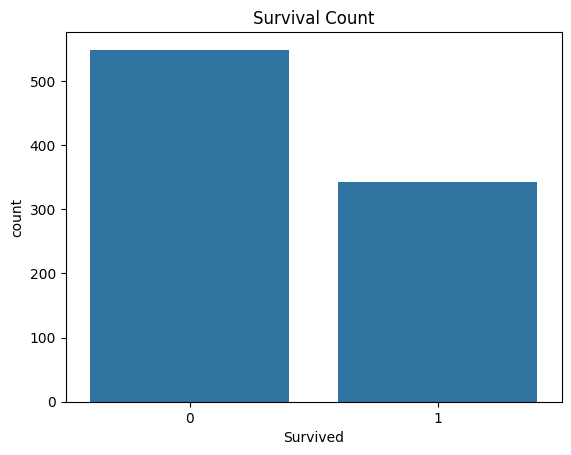

In [39]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

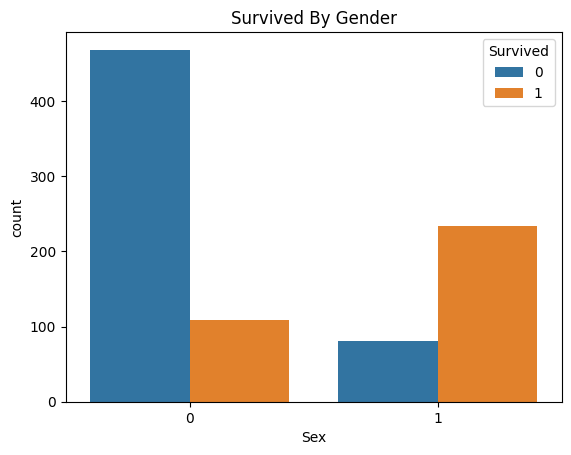

In [40]:
sns.countplot(x="Sex",hue="Survived",data=df)
plt.title("Survived By Gender")
plt.show()

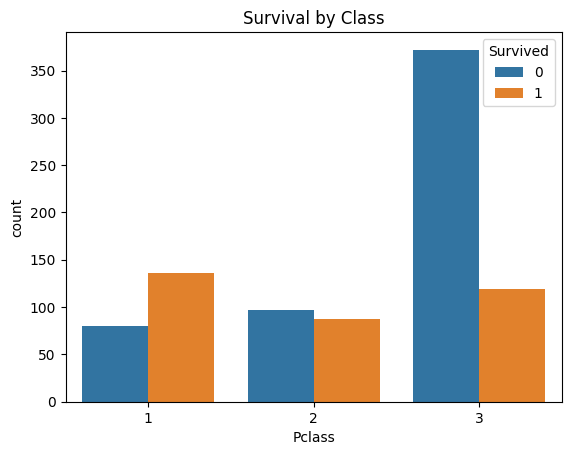

In [41]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Class")
plt.show()

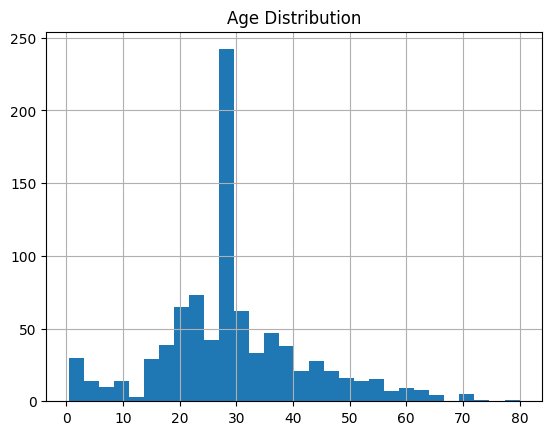

In [42]:
df['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [44]:
X = df[['Age', 'Sex', 'Pclass', 'Fare', 'FamilySize']]
y = df['Survived']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Impute NaN values in the 'Sex' column with the mode of the training set
sex_mode_train = X_train['Sex'].mode()[0]
X_train['Sex'].fillna(sex_mode_train, inplace=True)
X_test['Sex'].fillna(sex_mode_train, inplace=True)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7821229050279329
Confusion Matrix:
 [[100  14]
 [ 25  40]]


/tmp/ipykernel_3003/548887545.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Sex'].fillna(sex_mode_train, inplace=True)
/tmp/ipykernel_3003/548887545.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc}")

Logistic Regression: 0.7821229050279329
Decision Tree: 0.7597765363128491
Random Forest: 0.7932960893854749
KNN: 0.7262569832402235


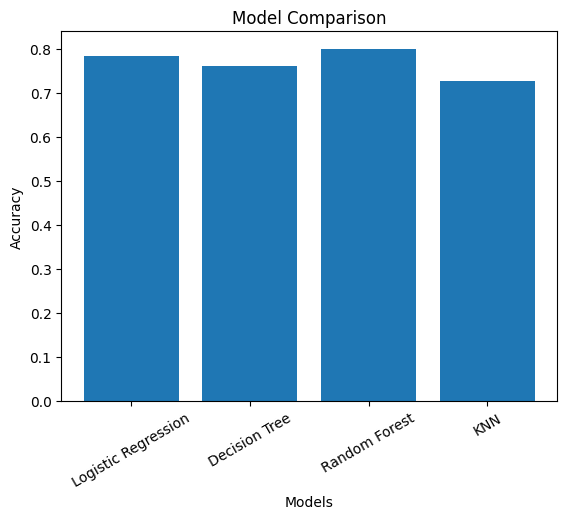

In [49]:
names = list(results.keys())
scores = list(results.values())

plt.bar(names, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

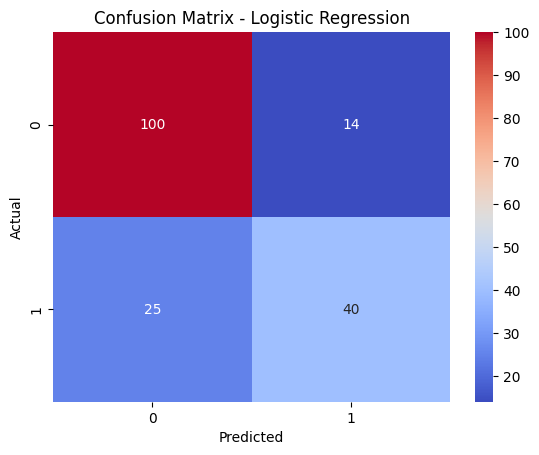

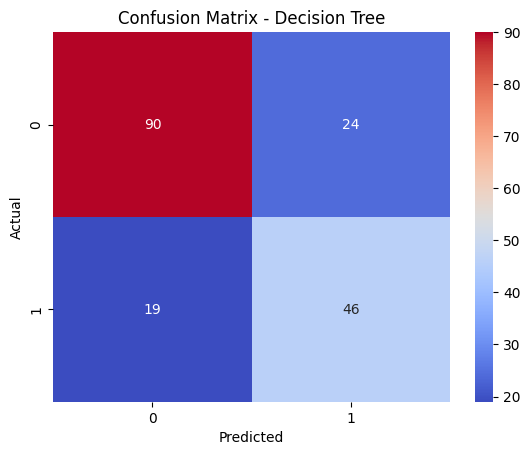

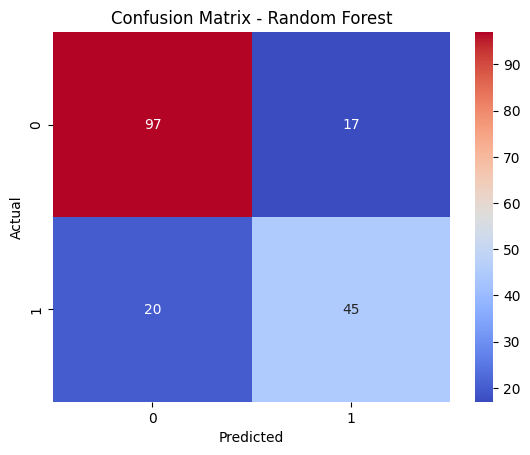

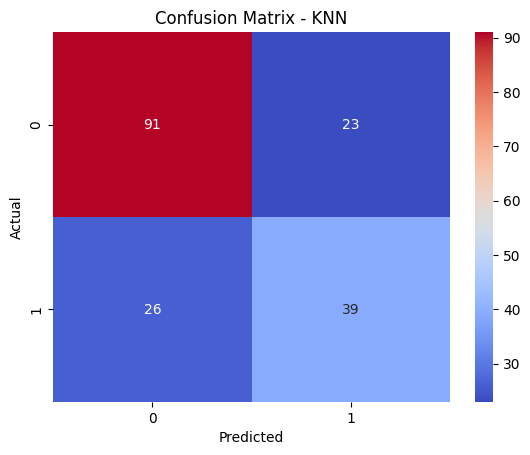

In [52]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()